Dataset: amsterdam
Label: pick


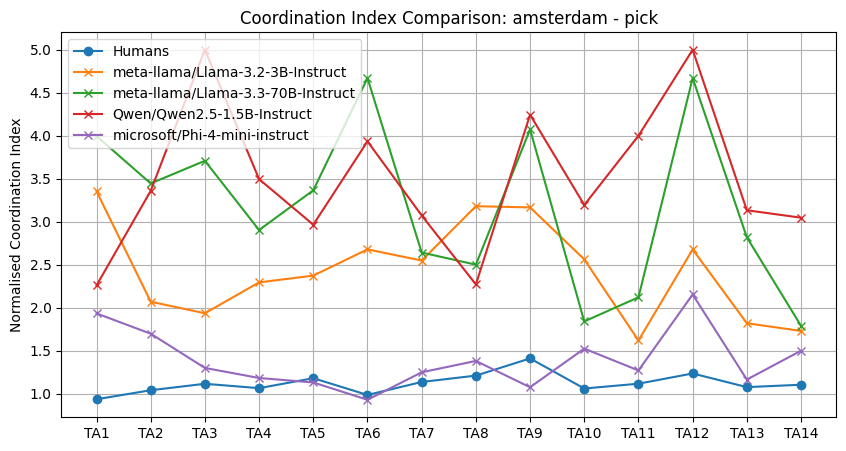

Label: guess


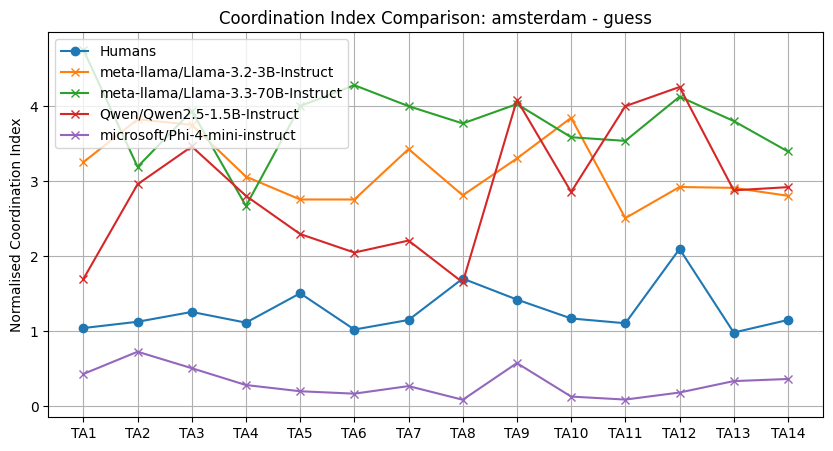

Label: coordinate


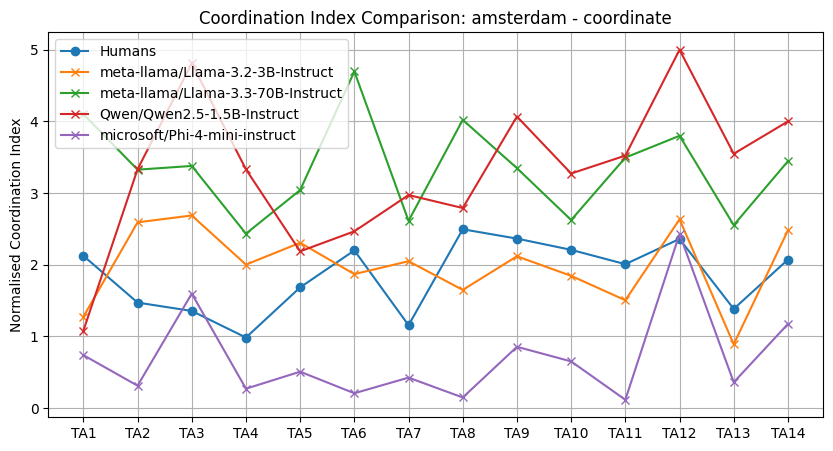

Dataset: nottingham
Label: pick


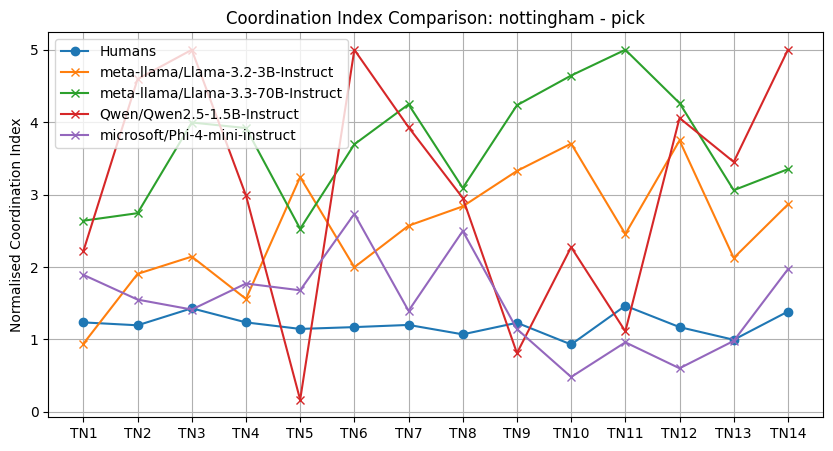

Label: guess


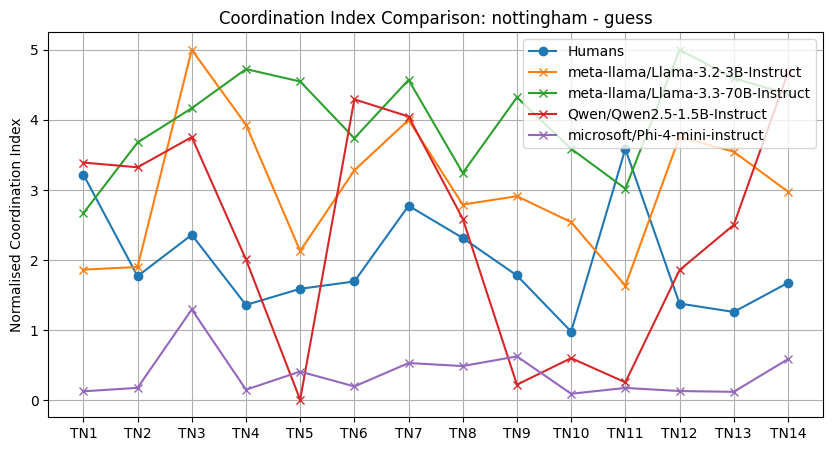

Label: coordinate


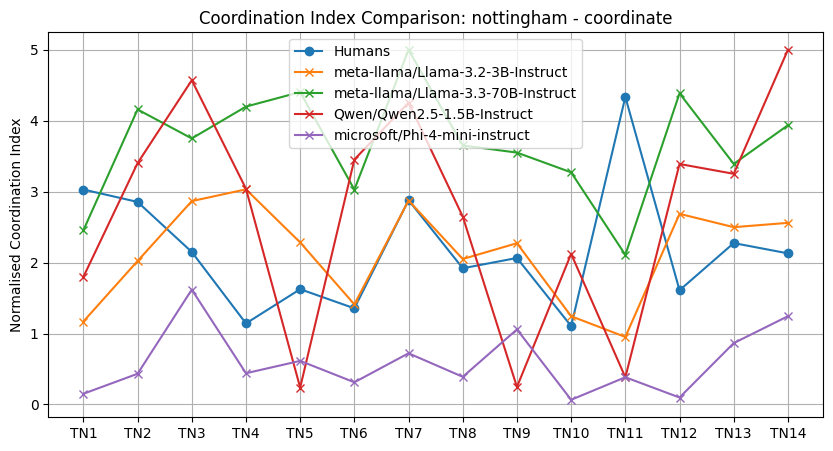

In [1]:
import json
import matplotlib.pyplot as plt

model_names = ["meta-llama/Llama-3.2-3B-Instruct", 
               "meta-llama/Llama-3.3-70B-Instruct",
               "Qwen/Qwen2.5-1.5B-Instruct",
               "microsoft/Phi-4-mini-instruct",
               "google/gemma-3-4b-it"]
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

data_llms = {}
for d_name in dataset_names:
    
    print(f"Dataset: {d_name}")
    for l in labels:
        
        print(f"Label: {l}")
        
        # Various LLM results
        for model_name in model_names:
            with open(f"./results/{model_name}/{d_name}_problem-{l}.jsonl", "r") as f:
                data_llm = json.load(f)
                
            data_llms[model_name] = []
            for i in range(0, len(data_llm), 3):
                data_llms[model_name].append(sum([d["normalised_coordination_index"] for d in data_llm[i:i+3]])/3)
        
        # Human data 
        with open(f"./data/Bardsley-humans/{d_name}.jsonl", "r") as f:
            data_humans = json.load(f)
        
        current_data_humans = []
        for d in data_humans:
            if d["task"] == l:
                current_data_humans.append(d["normalised_coordination_index"])
        
        # Plot the results with matplotlib
        plt.figure(figsize=(10, 5))
        plt.plot(current_data_humans, label="Humans", marker='o')
        
        for model_name in model_names:
            current_data_llm = data_llms[model_name]
            plt.plot(current_data_llm, label=model_name, marker='x')
            
        plt.xticks([i for i in range(14)], [f"T{d_name[0].upper()}{i+1}" for i in range(14)])
        plt.title(f"Coordination Index Comparison: {d_name} - {l}")
        plt.ylabel("Normalised Coordination Index")
        plt.legend()
        plt.grid()
        plt.show()

Dataset: amsterdam
Label: pick


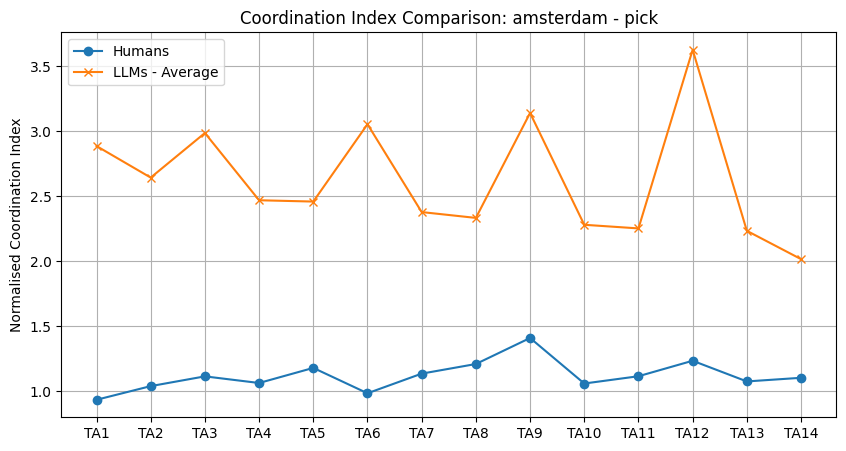

Label: guess


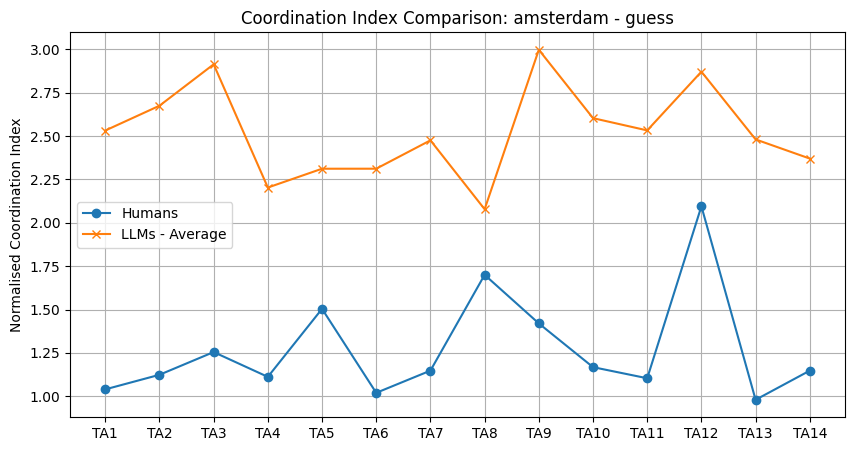

Label: coordinate


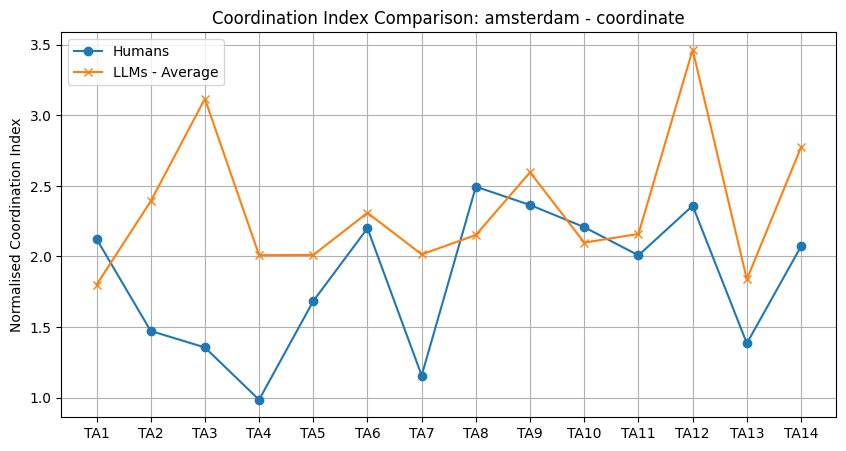

Dataset: nottingham
Label: pick


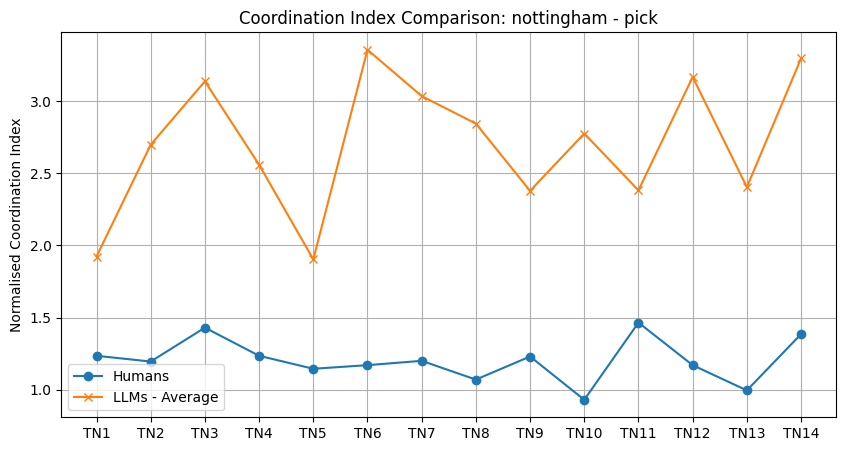

Label: guess


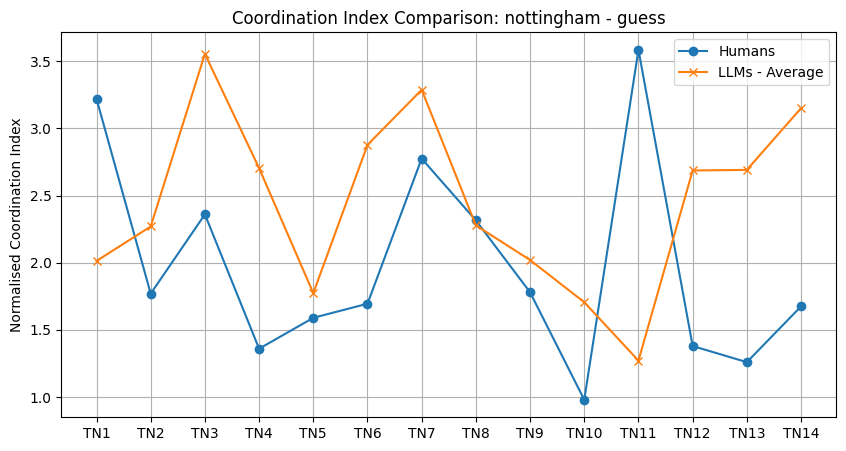

Label: coordinate


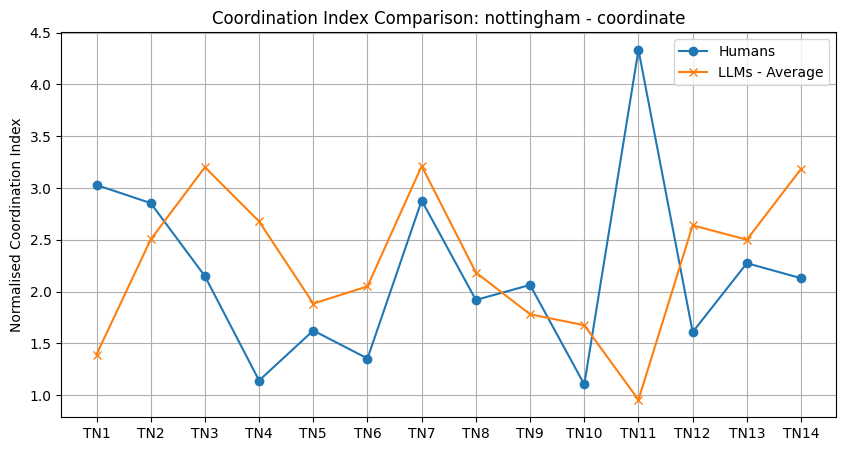

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

model_names = ["meta-llama/Llama-3.2-3B-Instruct", 
               "meta-llama/Llama-3.3-70B-Instruct",
               "Qwen/Qwen2.5-1.5B-Instruct",
               "microsoft/Phi-4-mini-instruct",
               "google/gemma-3-4b-it"]
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

data_llms = {}
for d_name in dataset_names:
    
    print(f"Dataset: {d_name}")
    for l in labels:
        
        print(f"Label: {l}")
        
        # Various LLM results
        for model_name in model_names:
            with open(f"./results/{model_name}/{d_name}_problem-{l}.jsonl", "r") as f:
                data_llm = json.load(f)
                
            data_llms[model_name] = []
            for i in range(0, len(data_llm), 3):
                data_llms[model_name].append(sum([d["normalised_coordination_index"] for d in data_llm[i:i+3]])/3)
        
        # Human data 
        with open(f"./data/Bardsley-humans/{d_name}.jsonl", "r") as f:
            data_humans = json.load(f)
        
        current_data_humans = []
        for d in data_humans:
            if d["task"] == l:
                current_data_humans.append(d["normalised_coordination_index"])
        
        # Plot the results with matplotlib
        plt.figure(figsize=(10, 5))
        plt.plot(current_data_humans, label="Humans", marker='o')
        
        all_data = []
        for model_name in model_names:
            all_data.append(data_llms[model_name])
            
        plt.plot(np.mean(all_data, axis=0), label="LLMs - Average", marker='x')    
        plt.xticks([i for i in range(14)], [f"T{d_name[0].upper()}{i+1}" for i in range(14)])
        plt.title(f"Coordination Index Comparison: {d_name} - {l}")
        plt.ylabel("Normalised Coordination Index")
        plt.legend()
        plt.grid()
        plt.show()